# Notebook Classification

In aceasta parte a temei, partea de clasificare va fi facuta pe un dataset cu meciuri de fotbal din Anglia. Contine mai multe meciuri, din mai multi ani, inclusiv anii 90'. Scopul e sa facem o clasificare, sa stim tipul de rezultat final dintre 2 echipe din Premier League.

Link-ul de unde se poate gasi acest dataset este : https://www.kaggle.com/datasets/panaaaaa/english-premier-league-and-championship-full-dataset/data?select=England+CSV.csv

- Contine mai multe date, cum ar fi : data, sezon, cartonare rosii, galbene, fault-uri, cornere, etc. . Totusi, pe unele dintre ele, cum ar fi nr de cartonase, nu avem cum sa le cunoastem de dinainte.
- O metoda de optimizare, este de ex. sa luam media faulturilor sau cartonaselor rosii. De exemplu, daca media cartonaselor rosii din ultimele 5 meciuri e mare atunci exista o tendinta sa piarda acel meci, deoarece exista o probabilitate mare sa ia echipa respectiva un cartonas rosu.
- Coloana pe care dorim sa o prezicem este : ***FT Result***

Astfel, in urma acestui notebook, vom afla top 5 modele de ML care prezic cel mai bun rezultat.


In [86]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

df = pd.read_csv('../Datasets/England CSV.csv')
print(f'Shape: {df.shape}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Shape: (12153, 25)


#### Coloanele:

In [87]:
df.columns

Index(['Date', 'Season', 'HomeTeam', 'AwayTeam', 'FTH Goals', 'FTA Goals',
       'FT Result', 'HTH Goals', 'HTA Goals', 'HT Result', 'Referee',
       'H Shots', 'A Shots', 'H SOT', 'A SOT', 'H Fouls', 'A Fouls',
       'H Corners', 'A Corners', 'H Yellow', 'A Yellow', 'H Red', 'A Red',
       'Display_Order', 'League'],
      dtype='str')

#### Tipurile de date pentru fiecare coloana:
- putem observa ca unele tipuri de date au si null, deoarece nu sunt 12153, ci mai putine.

In [88]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12153 entries, 0 to 12152
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           12153 non-null  str    
 1   Season         12153 non-null  str    
 2   HomeTeam       12153 non-null  str    
 3   AwayTeam       12153 non-null  str    
 4   FTH Goals      12153 non-null  int64  
 5   FTA Goals      12153 non-null  int64  
 6   FT Result      12153 non-null  str    
 7   HTH Goals      11229 non-null  float64
 8   HTA Goals      11229 non-null  float64
 9   HT Result      11229 non-null  str    
 10  Referee        9329 non-null   str    
 11  H Shots        9329 non-null   float64
 12  A Shots        9329 non-null   float64
 13  H SOT          9329 non-null   float64
 14  A SOT          9329 non-null   float64
 15  H Fouls        9329 non-null   float64
 16  A Fouls        9329 non-null   float64
 17  H Corners      9329 non-null   float64
 18  A Corners      93

In [89]:
df.head()

,Date,Season,HomeTeam,AwayTeam,FTH Goals,FTA Goals,FT Result,HTH Goals,HTA Goals,HT Result,...,H Fouls,A Fouls,H Corners,A Corners,H Yellow,A Yellow,H Red,A Red,Display_Order,League
0,16/01/2025,2024/25,Ipswich Town,Brighton & Hove Albion,0,2,A,0.0,1.0,A,...,13.0,14.0,1.0,9.0,2.0,2.0,0.0,0.0,20250116,Premier League
1,16/01/2025,2024/25,Man United,Southampton,3,1,H,0.0,1.0,A,...,7.0,10.0,4.0,4.0,1.0,3.0,0.0,0.0,20250116,Premier League
2,15/01/2025,2024/25,Everton,Aston Villa,0,1,A,0.0,0.0,D,...,17.0,10.0,8.0,5.0,2.0,1.0,0.0,0.0,20250115,Premier League
3,15/01/2025,2024/25,Leicester,Crystal Palace,0,2,A,0.0,0.0,D,...,7.0,6.0,4.0,3.0,0.0,0.0,0.0,0.0,20250115,Premier League
4,15/01/2025,2024/25,Newcastle,Wolves,3,0,H,1.0,0.0,H,...,10.0,13.0,4.0,2.0,0.0,2.0,0.0,0.0,20250115,Premier League


### Analiza calitativa / curatarea datelor:
- se obs ca datele sunt null unde sunt meciuri de mult timp , ex din 96', cand nu se puteau colecta datele.
- in plus, pentru predictia actuala nu conteaza, nu are vreo importanta, deci vom elimina randurile acelea

In [90]:
df.isnull().sum()

Date                0
Season              0
HomeTeam            0
AwayTeam            0
FTH Goals           0
FTA Goals           0
FT Result           0
HTH Goals         924
HTA Goals         924
HT Result         924
Referee          2824
H Shots          2824
A Shots          2824
H SOT            2824
A SOT            2824
H Fouls          2824
A Fouls          2824
H Corners        2824
A Corners        2824
H Yellow         2824
A Yellow         2824
H Red            2824
A Red            2824
Display_Order       0
League              0
dtype: int64

In [91]:
df.dropna(inplace=True)
df.shape

(9329, 25)

#### Acum nu mai exista randuri cu valori null si ar fi toate date relevante

In [92]:
df.isnull().sum()

Date             0
Season           0
HomeTeam         0
AwayTeam         0
FTH Goals        0
FTA Goals        0
FT Result        0
HTH Goals        0
HTA Goals        0
HT Result        0
Referee          0
H Shots          0
A Shots          0
H SOT            0
A SOT            0
H Fouls          0
A Fouls          0
H Corners        0
A Corners        0
H Yellow         0
A Yellow         0
H Red            0
A Red            0
Display_Order    0
League           0
dtype: int64

### Acum vom renunta la coloanele care nu sunt folositoare, de exemplu: arbitrul, liga, display order , iar data o vom sterge la final.

In [93]:
df = df.drop(['Referee','League','Display_Order'],axis=1)
df.shape

(9329, 22)

# Analiza exploratorie

- dorim sa vedem cum sunt corelate datele, legaturile dintre coloane
- mai jos se vede ca echipa de acaca are o tendinta mai buna pe orice statistica, mai putin la fault uri
- deviatia standard de ajuta la goluri, deoarece datele nu sunt asa imprastiate

In [94]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
FTH Goals,9329.0,1.536178,1.305748,0.0,1.0,1.0,2.0,9.0
FTA Goals,9329.0,1.179333,1.157003,0.0,0.0,1.0,2.0,9.0
HTH Goals,9329.0,0.687641,0.835261,0.0,0.0,0.0,1.0,5.0
HTA Goals,9329.0,0.518491,0.734551,0.0,0.0,0.0,1.0,5.0
H Shots,9329.0,13.618716,5.349420,0.0,10.0,13.0,17.0,43.0
A Shots,9329.0,10.784543,4.678710,0.0,7.0,10.0,14.0,31.0
H SOT,9329.0,6.007503,3.275177,0.0,4.0,6.0,8.0,24.0
A SOT,9329.0,4.704684,2.757288,0.0,3.0,4.0,6.0,20.0
H Fouls,9329.0,11.303462,3.752442,0.0,9.0,11.0,14.0,33.0
A Fouls,9329.0,11.781113,3.931377,1.0,9.0,12.0,14.0,29.0


Asimetria este doar pozitiva pentru ca nu exista ca nr de goluri sa fie negative.

In [95]:
df.skew(numeric_only=True)

FTH Goals    0.975128
FTA Goals    1.076766
HTH Goals    1.217881
HTA Goals    1.481468
H Shots      0.642805
A Shots      0.655182
H SOT        0.823543
A SOT        0.873413
H Fouls      0.437434
A Fouls      0.406391
H Corners    0.615626
A Corners    0.737246
H Yellow     0.769340
A Yellow     0.623094
H Red        4.147739
A Red        3.337277
dtype: float64

Majoritatea echipelor de acasa castiga.Asta influenteaza mult, unde se joaca.

In [96]:
df["FT Result"].value_counts()

FT Result
H    4278
A    2738
D    2313
Name: count, dtype: int64

La pauza exista mai multe partide la un rezultat de egalitate.

In [97]:
df["HT Result"].value_counts()

HT Result
D    3818
H    3268
A    2243
Name: count, dtype: int64

Mai jos se pot observa urmatoarele :
- foarte rar conduce echipa de acasa la pauza si ea tot pierde. Adica daca away conduce la pauza, in maj cazurilor, mai bine de jumate, castiga si meciul.
- daca echipa de acasa castiga la pauza , are cele mai mari sanse sa castige meciul.
- cele mai multe sunt egaluri la pauza.
- cele mai multe victorii la final sunt la gazde.

In [98]:
pd.crosstab(df['HT Result'], df['FT Result'], margins=True)

FT Result,A,D,H,All
HT Result,,,,
A,1565,443,235,2243
D,994,1405,1419,3818
H,179,465,2624,3268
All,2738,2313,4278,9329


Grafic pentru rezultatul final, la fel ca la value_counts.

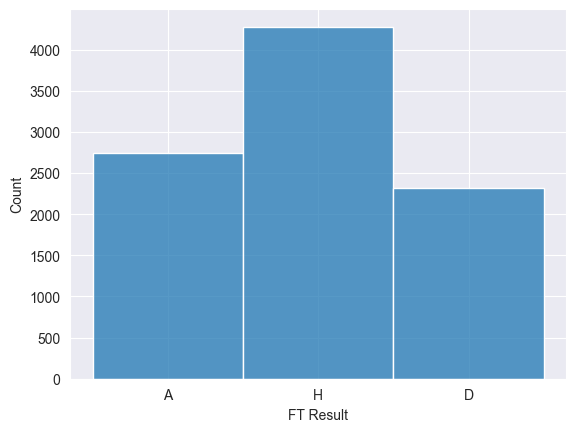

In [99]:
sns.histplot(data = df, x="FT Result")
plt.show()

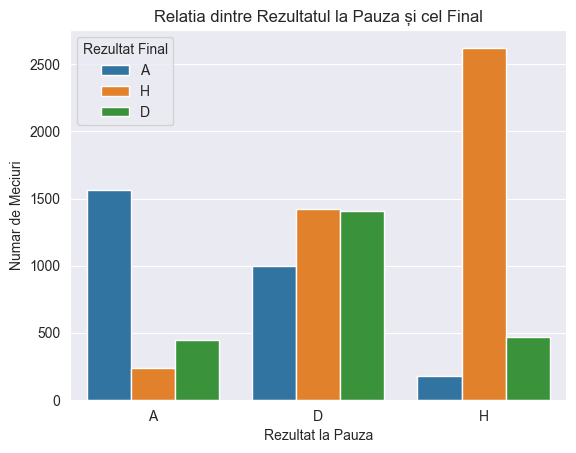

In [100]:
sns.countplot(data=df, x='HT Result', hue='FT Result')

plt.title('Relatia dintre Rezultatul la Pauza și cel Final')
plt.xlabel('Rezultat la Pauza')
plt.ylabel('Numar de Meciuri')
plt.legend(title='Rezultat Final')
plt.show()

Exista relatii intre :
- goluri si suturi
- suturi si cornere
- nr de suturi la pauza si final

<Axes: >

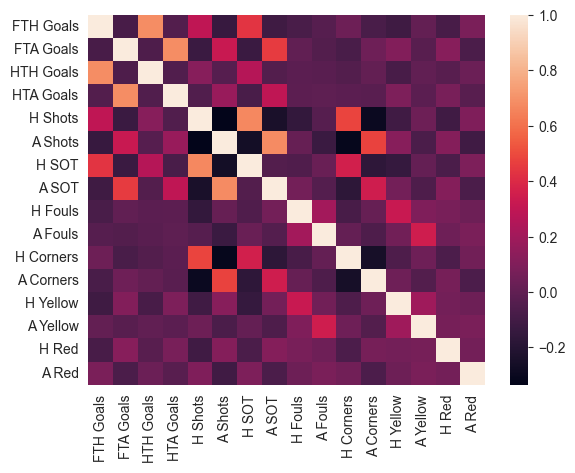

In [101]:
sns.heatmap(df.corr(numeric_only=True))

### Encodare :
- cu datele actuale nu ne putem da seama neaparat de relatii foarte specifice si vom encoda echipele, H,A,D

In [102]:
res_grid = {'H' : 0, 'D':1, 'A':2}
df['FT Result'] = df['FT Result'].str.strip()
df['HT Result'] = df['HT Result'].str.strip()
df['FT Result'] = df['FT Result'].map(res_grid)
df['HT Result'] = df['HT Result'].map(res_grid)


In [103]:
df.head(7)

,Date,Season,HomeTeam,AwayTeam,FTH Goals,FTA Goals,FT Result,HTH Goals,HTA Goals,HT Result,...,H SOT,A SOT,H Fouls,A Fouls,H Corners,A Corners,H Yellow,A Yellow,H Red,A Red
0,16/01/2025,2024/25,Ipswich Town,Brighton & Hove Albion,0,2,2,0.0,1.0,2,...,3.0,5.0,13.0,14.0,1.0,9.0,2.0,2.0,0.0,0.0
1,16/01/2025,2024/25,Man United,Southampton,3,1,0,0.0,1.0,2,...,9.0,5.0,7.0,10.0,4.0,4.0,1.0,3.0,0.0,0.0
2,15/01/2025,2024/25,Everton,Aston Villa,0,1,2,0.0,0.0,1,...,3.0,3.0,17.0,10.0,8.0,5.0,2.0,1.0,0.0,0.0
3,15/01/2025,2024/25,Leicester,Crystal Palace,0,2,2,0.0,0.0,1,...,4.0,4.0,7.0,6.0,4.0,3.0,0.0,0.0,0.0,0.0
4,15/01/2025,2024/25,Newcastle,Wolves,3,0,0,1.0,0.0,0,...,5.0,7.0,10.0,13.0,4.0,2.0,0.0,2.0,0.0,0.0
5,15/01/2025,2024/25,Arsenal,Tottenham,2,1,0,2.0,1.0,0,...,4.0,2.0,16.0,9.0,10.0,4.0,3.0,1.0,0.0,0.0
6,14/01/2025,2024/25,Brentford,Man City,2,2,1,0.0,0.0,1,...,6.0,8.0,4.0,4.0,4.0,5.0,0.0,0.0,0.0,0.0


- pentru a codifica corect echipele si pt a avea acelasi cod si la home si la away facem un dictionar prin reuniune si apoi codificam tot

In [104]:
common_set = set(df['HomeTeam']).union(set(df['AwayTeam']))
print(common_set)

{'West Brom', 'Derby', 'Norwich', 'Brighton & Hove Albion', 'Leicester', 'Portsmouth', 'Charlton', "Nott'm Forest", 'Watford', 'Reading', 'West Ham', 'Leeds', 'Fulham', 'Bournemouth', 'Brentford', 'Hull', 'Sunderland', 'Middlesbrough', 'QPR', 'Blackpool', 'Burnley', 'Brighton', 'Liverpool', 'Wolves', 'Stoke', 'Ipswich', 'Arsenal', 'Aston Villa', 'Cardiff', 'Newcastle', 'Southampton', 'Luton', 'Bolton', 'Bradford', 'Tottenham', 'Man United', 'Coventry', 'Ipswich Town', 'Birmingham', 'Chelsea', 'Sheffield United', 'Crystal Palace', 'Man City', 'Everton', 'Wigan', 'Swansea', 'Huddersfield', 'Blackburn'}


In [105]:
sorted_teams = sorted(list(common_set))
team_grid = {team:i for i, team in enumerate(sorted_teams)}
print(team_grid)

{'Arsenal': 0, 'Aston Villa': 1, 'Birmingham': 2, 'Blackburn': 3, 'Blackpool': 4, 'Bolton': 5, 'Bournemouth': 6, 'Bradford': 7, 'Brentford': 8, 'Brighton': 9, 'Brighton & Hove Albion': 10, 'Burnley': 11, 'Cardiff': 12, 'Charlton': 13, 'Chelsea': 14, 'Coventry': 15, 'Crystal Palace': 16, 'Derby': 17, 'Everton': 18, 'Fulham': 19, 'Huddersfield': 20, 'Hull': 21, 'Ipswich': 22, 'Ipswich Town': 23, 'Leeds': 24, 'Leicester': 25, 'Liverpool': 26, 'Luton': 27, 'Man City': 28, 'Man United': 29, 'Middlesbrough': 30, 'Newcastle': 31, 'Norwich': 32, "Nott'm Forest": 33, 'Portsmouth': 34, 'QPR': 35, 'Reading': 36, 'Sheffield United': 37, 'Southampton': 38, 'Stoke': 39, 'Sunderland': 40, 'Swansea': 41, 'Tottenham': 42, 'Watford': 43, 'West Brom': 44, 'West Ham': 45, 'Wigan': 46, 'Wolves': 47}


In [106]:
df["HomeTeam"] = df['HomeTeam'].astype(str).str.strip()
df["AwayTeam"] = df['AwayTeam'].astype(str).str.strip()
df['HomeTeam'] = df['HomeTeam'].map(team_grid)
df['AwayTeam'] = df['AwayTeam'].map(team_grid)

In [107]:
df.head(7)

,Date,Season,HomeTeam,AwayTeam,FTH Goals,FTA Goals,FT Result,HTH Goals,HTA Goals,HT Result,...,H SOT,A SOT,H Fouls,A Fouls,H Corners,A Corners,H Yellow,A Yellow,H Red,A Red
0,16/01/2025,2024/25,23,10,0,2,2,0.0,1.0,2,...,3.0,5.0,13.0,14.0,1.0,9.0,2.0,2.0,0.0,0.0
1,16/01/2025,2024/25,29,38,3,1,0,0.0,1.0,2,...,9.0,5.0,7.0,10.0,4.0,4.0,1.0,3.0,0.0,0.0
2,15/01/2025,2024/25,18,1,0,1,2,0.0,0.0,1,...,3.0,3.0,17.0,10.0,8.0,5.0,2.0,1.0,0.0,0.0
3,15/01/2025,2024/25,25,16,0,2,2,0.0,0.0,1,...,4.0,4.0,7.0,6.0,4.0,3.0,0.0,0.0,0.0,0.0
4,15/01/2025,2024/25,31,47,3,0,0,1.0,0.0,0,...,5.0,7.0,10.0,13.0,4.0,2.0,0.0,2.0,0.0,0.0
5,15/01/2025,2024/25,0,42,2,1,0,2.0,1.0,0,...,4.0,2.0,16.0,9.0,10.0,4.0,3.0,1.0,0.0,0.0
6,14/01/2025,2024/25,8,28,2,2,1,0.0,0.0,1,...,6.0,8.0,4.0,4.0,4.0,5.0,0.0,0.0,0.0,0.0


### Dupa codificare :
Dupa aceasta etapa urmeaza etapa de a adauga date noi , din urma carora sa rezulte relatii intre coloane.Vom incerca sa adaugam:
- rezultatul ultimelor 5 partite a echipei, inainte de meciul respectiv(0p = Lose, 1p = Draw, 3p = Win) pentru fiecare echipa
- nr de cartonase rosii in ultimele 5 meciuri pentru fiecare echipa
- H2H: ultimele 5 rezultate intre cele 2 echipe (0 = echipa din away a castigat toate meciurile directe, 1= echipa de acasa a catigat 1/5 meciuri directe si tot asa.)
- nr de goluri marcate de fiecare echipa in ultimele 5 meciuri
- nr de goluri primite de fiecare echipa in ultimele 5 meciuri

Inainte de stergerea coloanelor trebuie sa adaugam noile statistici din datele brute:

In [109]:
from Classes.FootballFeature import FootballFeature
from Classes.Utils import create_columns

features = FootballFeature(df)
df = create_columns(df,features,n=5)



### Stergem coloanele de date brute:

In [110]:
df = df.drop(columns=['FTH Goals', 'FTA Goals', 'HTH Goals', 'HTA Goals','HT Result',
              'HTH Goals', 'HTA Goals', 'HT Result',
              'H Shots', 'A Shots','H SOT', 'A SOT',
              'H Corners', 'A Corners','H Fouls', 'A Fouls', 'H Yellow', 'A Yellow', 'H Red', 'A Red',
              'Date','Season'])

Cum arata noul tabel:

In [111]:
df.head(5)

,HomeTeam,AwayTeam,FT Result,H_Scored_Avg,A_Scored_Avg,H_Conceded_Avg,A_Conceded_Avg,H_Points_Avg,A_Points_Avg,H_Red_Avg,A_Red_Avg,H2H_Score,Diff_Form,Diff_Scored,Diff_Conceded
1,29,38,0,0.8,0.2,2.0,2.6,0.8,0.2,0.2,0.0,2,0.6,0.6,-0.6
2,18,1,2,0.2,1.4,0.8,1.8,0.6,1.4,0.0,0.2,0,-0.8,-1.2,-1.0
3,25,16,2,0.4,1.4,2.8,1.6,0.0,1.6,0.0,0.0,1,-1.6,-1.0,1.2
4,31,47,0,3.0,1.6,0.2,1.4,3.0,1.4,0.0,0.2,3,1.6,1.4,-1.2
5,0,42,0,2.0,2.2,0.6,2.2,2.2,0.8,0.0,0.2,4,1.4,-0.2,-1.6


Acum avem 15 coloane, cu datele din trecut si putem prezice pe baza acestor statistici.

In [113]:
df.shape

(9049, 15)

<Axes: >

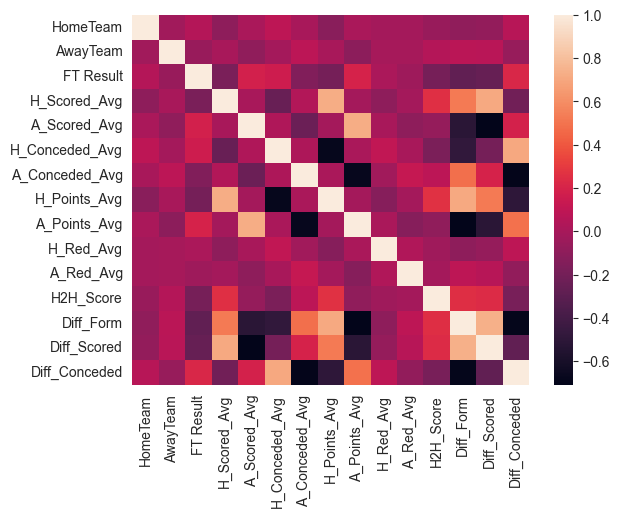

In [114]:
sns.heatmap(df.corr(numeric_only=True))


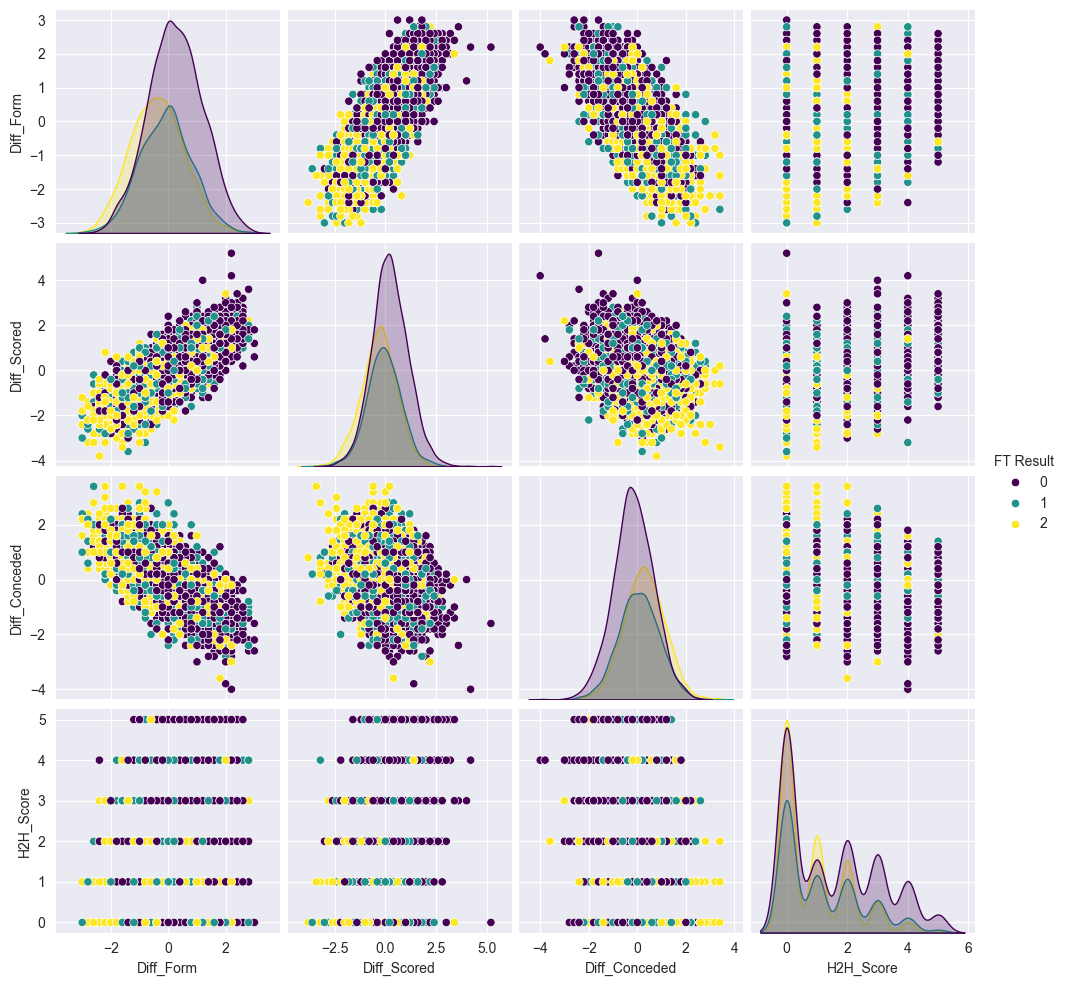

In [115]:
key_features = ['Diff_Form', 'Diff_Scored', 'Diff_Conceded', 'H2H_Score', 'FT Result']
sns.pairplot(df[key_features], hue='FT Result', palette='viridis', diag_kind='kde')
plt.show()